In [9]:
import pandas as pd

TARGET = "Paddy yield(in Kg)"
HECTARES = "Hectares "

df = pd.read_csv("../data/transformed/paddy_preprocessed.csv")

In [10]:
#continuous inputs fetched from 02_file
continuous_inputs = ['LP_Mainfield(in Tonnes)', 'Urea_40Days', 'Potassh_50Days',
       '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)',
       '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)',
       '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30',
       'Min temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90',
       'Min temp_D91_D120', 'Max temp_D91_D120', 'Relative Humidity_D1_D30']

In [11]:
continuous_non_weather_inputs = [
    "LP_Mainfield(in Tonnes)", "Urea_40Days", "Potassh_50Days",
    "Seedrate(in Kg)", "Nursery area (Cents)", "LP_nurseryarea(in Tonnes)",
    "DAP_20days", "Weed28D_thiobencarb", "Micronutrients_70Days",
    "Pest_60Day(in ml)"
]

In [12]:
# Normalize continuous inputs by hectares

for col in continuous_non_weather_inputs:
    df[f"{col}_per_ha"] = df[col] / df[HECTARES]


#New target: yield per hectare
df["yield_per_ha"] = df[TARGET] / df[HECTARES]


cols_to_drop = continuous_non_weather_inputs + [HECTARES, TARGET, "Trash(in bundles)"]
#trash is after yield so it is not needed 


df_normalized = df.drop(columns=cols_to_drop)

print(df_normalized.shape)
print(df_normalized.head())

(2789, 62)
   30DRain( in mm)  30DAI(in mm)  30_50DRain( in mm)  30_50DAI(in mm)  \
0         1.361570     -1.361570            1.381531        -1.381531   
1         1.361570     -1.361570            1.381531        -1.381531   
2        -0.347370      0.347370           -0.953675         0.953675   
3        -0.347370      0.347370           -0.953675         0.953675   
4        -0.968802      0.968802           -0.486634         0.486634   

   51_70DRain(in mm)  51_70AI(in mm)  71_105DRain(in mm)  71_105DAI(in mm)  \
0           1.235600       -1.235600            1.381531         -1.381531   
1           1.235600       -1.235600            1.381531         -1.381531   
2          -1.270003        1.270003           -0.953675          0.953675   
3          -1.270003        1.270003           -0.953675          0.953675   
4          -0.090896        0.090896           -0.486634          0.486634   

   Min temp_D1_D30  Min temp_D31_D60  ...  Urea_40Days_per_ha  \
0        -0.9618

We know have a per-hectare version of all continuous inputs, yield_per_ha is my new target

In [13]:
df_normalized.to_csv("../data/after_inspection/paddy_normalized.csv", index=False)


## Rerunning feature selection on this modified/nromalized data with different target

Key things to note:

- Test set is saved separately and never touched again until model evaluation
- Every filter step only sees X_train — test is just transformed using the columns selected from train

In [55]:
from sklearn.model_selection import train_test_split

df_normalized = pd.read_csv("../data/after_inspection/paddy_normalized.csv")
X = df_normalized.drop(columns=["yield_per_ha"])
y = df_normalized["yield_per_ha"]

In [56]:
y

0       22060.270015
1       22302.109220
2       22861.362382
3       22052.712539
4       21440.557051
            ...     
2784    -3087.205173
2785    -3027.428925
2786    -3027.428925
2787    -3129.524641
2788    -3106.777927
Name: yield_per_ha, Length: 2789, dtype: float64

In [57]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
def detect_ohe_columns(X):
    return [col for col in X.columns 
            if set(X[col].dropna().unique()).issubset({0, 1})]

Pearson filter: 32 numeric cols → 21 selected (threshold=0.01)
Excluded 29 OHE-style columns: ['Agriblock_Cuddalore', 'Agriblock_Kallakurichi', 'Agriblock_Kurinjipadi', 'Agriblock_Panruti', 'Agriblock_Sankarapuram', 'Variety_delux ponni', 'Variety_ponmani', 'Soil Types_clay', 'Nursery_wet', 'Wind Direction_D1_D30_ENE', 'Wind Direction_D1_D30_NW', 'Wind Direction_D1_D30_SSE', 'Wind Direction_D1_D30_SW', 'Wind Direction_D1_D30_W', 'Wind Direction_D31_D60_NE', 'Wind Direction_D31_D60_S', 'Wind Direction_D31_D60_W', 'Wind Direction_D31_D60_WNW', 'Wind Direction_D61_D90_NNE', 'Wind Direction_D61_D90_NNW', 'Wind Direction_D61_D90_SE', 'Wind Direction_D61_D90_SW', 'Wind Direction_D91_D120_NW', 'Wind Direction_D91_D120_S', 'Wind Direction_D91_D120_SSE', 'Wind Direction_D91_D120_W', 'Wind Direction_D91_D120_WSW', 'LP_nurseryarea(in Tonnes)_per_ha', 'Weed28D_thiobencarb_per_ha']


C:\Users\soham_ai\AppData\Local\Temp\ipykernel_21752\3257593251.py:25: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr, _ = pearsonr(X_train[col], y_train)


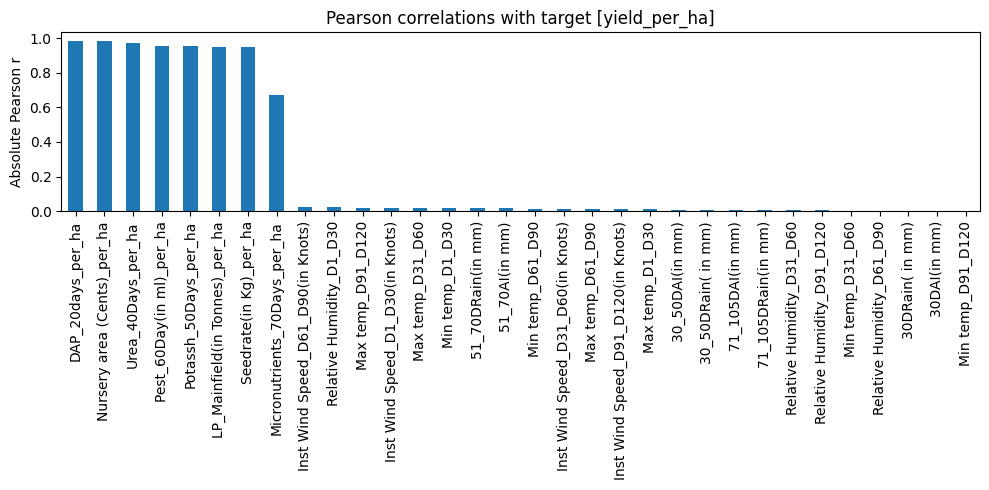

In [59]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt


def pearson_filter(X_train, y_train, threshold=0.01):
    """Remove features with near-zero absolute Pearson correlation with target.

    Args:
        X_train: training features
        y_train: training target
        threshold: minimum absolute correlation to keep a feature

    Returns:
        Tuple (selected_features, corr_series)
    """
    # Exclude one-hot encoded columns (categorical dummies)
    ohe_cols = detect_ohe_columns(X_train)
    candidate_cols = [c for c in X_train.columns if c not in ohe_cols]

    correlations = {}
    for col in candidate_cols:
        # Skip constant columns (pearsonr cannot compute)
        if X_train[col].dropna().nunique() <= 1:
            continue
        corr, _ = pearsonr(X_train[col], y_train)
        correlations[col] = abs(corr)

    corr_series = pd.Series(correlations).sort_values(ascending=False)
    selected = corr_series[corr_series >= threshold].index.tolist()

    print(f"Pearson filter: {len(candidate_cols)} numeric cols → {len(selected)} selected (threshold={threshold})")
    print(f"Excluded {len(ohe_cols)} OHE-style columns: {ohe_cols}")

    # Visualization: show top correlations
    plt.figure(figsize=(10, 5))
    corr_series.plot(kind="bar")
    plt.title("Pearson correlations with target [yield_per_ha]")
    plt.ylabel("Absolute Pearson r")
    plt.tight_layout()
    plt.show()

    return selected, corr_series

pearson_cols, pearson_corr = pearson_filter(X_train, y_train, threshold=0.01)

# Add OHE columns back
ohe_cols = detect_ohe_columns(X_train)
final_pearson_cols = pearson_cols + ohe_cols

X_train_pearson = X_train[final_pearson_cols]
X_test_pearson  = X_test[final_pearson_cols]

In [60]:
pearson_corr.head(20)

DAP_20days_per_ha                     0.983645
Nursery area (Cents)_per_ha           0.983645
Urea_40Days_per_ha                    0.973935
Pest_60Day(in ml)_per_ha              0.954859
Potassh_50Days_per_ha                 0.952015
LP_Mainfield(in Tonnes)_per_ha        0.947323
Seedrate(in Kg)_per_ha                0.947323
Micronutrients_70Days_per_ha          0.668402
Inst Wind Speed_D61_D90(in Knots)     0.025269
Relative Humidity_D1_D30              0.023727
Max temp_D91_D120                     0.021722
Inst Wind Speed_D1_D30(in Knots)      0.019648
Max temp_D31_D60                      0.018902
Min temp_D1_D30                       0.018199
51_70DRain(in mm)                     0.016540
51_70AI(in mm)                        0.016540
Min temp_D61_D90                      0.015519
Inst Wind Speed_D31_D60(in Knots)     0.014889
Max temp_D61_D90                      0.014592
Inst Wind Speed_D91_D120(in Knots)    0.014527
dtype: float64

In [61]:
X_train_pearson.shape[1]

50

### Implementing RF Regressor Feature Importance

In [62]:
from sklearn.ensemble import RandomForestRegressor


def rf_importance_filter(X_train, y_train, threshold=0.01):
    """
    Select features using Random Forest feature importances.

    Args:
        X_train: training features after Pearson filter
        y_train: training target
        threshold: minimum RF importance score to keep a feature

    Returns:
        fitted RF model, list of selected feature names
    """
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    selected = importances[importances >= threshold].sort_values(ascending=False)

    print(f"RF importance filter: {len(X_train.columns)} → {len(selected)} features")
    print(selected)
    return rf, selected.index.tolist()

rf_model, rf_cols = rf_importance_filter(X_train_pearson, y_train, threshold=0.005)

RF importance filter: 50 → 28 features
Soil Types_clay                       0.158663
Nursery_wet                           0.154195
Variety_ponmani                       0.151915
Variety_delux ponni                   0.138850
Relative Humidity_D1_D30              0.031248
Max temp_D61_D90                      0.024227
Max temp_D31_D60                      0.023555
Min temp_D1_D30                       0.023430
Max temp_D1_D30                       0.022985
Min temp_D61_D90                      0.022957
Inst Wind Speed_D1_D30(in Knots)      0.021223
51_70DRain(in mm)                     0.018565
Max temp_D91_D120                     0.018193
51_70AI(in mm)                        0.018184
Inst Wind Speed_D61_D90(in Knots)     0.017162
Wind Direction_D31_D60_W              0.016920
Inst Wind Speed_D91_D120(in Knots)    0.012061
Inst Wind Speed_D31_D60(in Knots)     0.011538
Wind Direction_D61_D90_SE             0.008829
Wind Direction_D1_D30_SW              0.007449
Wind Direction_D1_D30

Nursery_wet                           0.014906
Wind Direction_D91_D120_WSW          -0.000573
Wind Direction_D61_D90_NNW           -0.000674
Wind Direction_D1_D30_SW             -0.000688
Agriblock_Cuddalore                  -0.000693
Wind Direction_D31_D60_S             -0.000992
Agriblock_Kallakurichi               -0.001105
Wind Direction_D91_D120_SSE          -0.001431
Wind Direction_D61_D90_SE            -0.001480
Wind Direction_D1_D30_W              -0.001907
Wind Direction_D61_D90_NNE           -0.002376
Inst Wind Speed_D31_D60(in Knots)    -0.002802
Soil Types_clay                      -0.002825
Max temp_D91_D120                    -0.003890
Inst Wind Speed_D91_D120(in Knots)   -0.004017
51_70AI(in mm)                       -0.004223
Min temp_D61_D90                     -0.004937
Max temp_D61_D90                     -0.004969
Wind Direction_D31_D60_W             -0.005447
Variety_ponmani                      -0.005449
Min temp_D1_D30                      -0.005512
Max temp_D31_

Nursery_wet                           0.014906
Wind Direction_D91_D120_WSW          -0.000573
Wind Direction_D61_D90_NNW           -0.000674
Wind Direction_D1_D30_SW             -0.000688
Agriblock_Cuddalore                  -0.000693
Wind Direction_D31_D60_S             -0.000992
Agriblock_Kallakurichi               -0.001105
Wind Direction_D91_D120_SSE          -0.001431
Wind Direction_D61_D90_SE            -0.001480
Wind Direction_D1_D30_W              -0.001907
Wind Direction_D61_D90_NNE           -0.002376
Inst Wind Speed_D31_D60(in Knots)    -0.002802
Soil Types_clay                      -0.002825
Max temp_D91_D120                    -0.003890
Inst Wind Speed_D91_D120(in Knots)   -0.004017
51_70AI(in mm)                       -0.004223
Min temp_D61_D90                     -0.004937
Max temp_D61_D90                     -0.004969
Wind Direction_D31_D60_W             -0.005447
Variety_ponmani                      -0.005449
Min temp_D1_D30                      -0.005512
Max temp_D31_

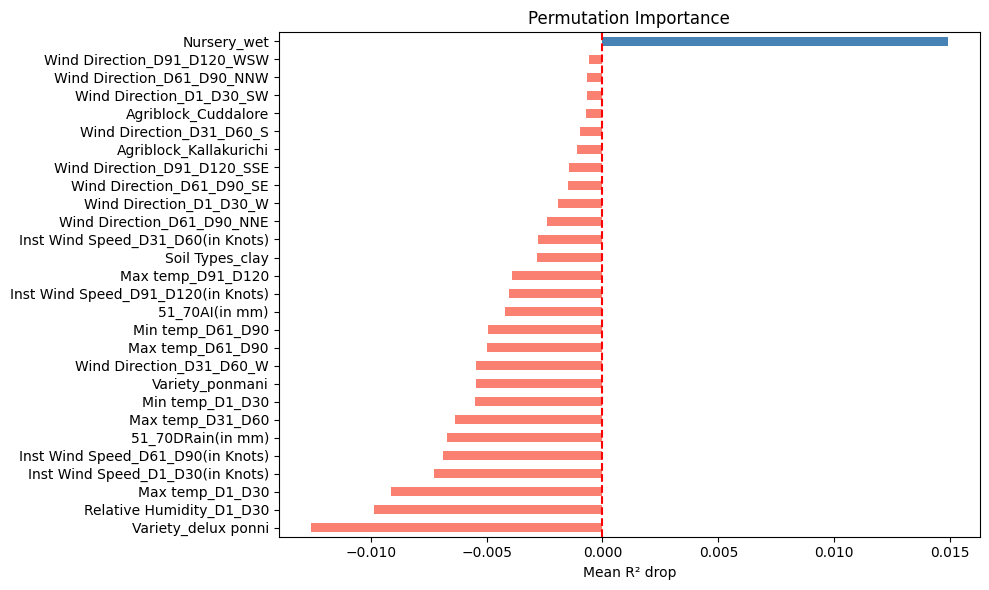


Selected 1 features after permutation filter


In [63]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_pearson[rf_cols], y_train)

perm = permutation_importance(
    rf_model, X_test_pearson[rf_cols], y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_series = pd.Series(perm.importances_mean, index=rf_cols).sort_values(ascending=False)
print(perm_series)

# Plot
plt.figure(figsize=(10, 6))
colors = ["steelblue" if v > 0 else "salmon" for v in perm_series]
perm_series.plot(kind="barh", color=colors)
plt.axvline(0, color="red", linestyle="--")
plt.gca().invert_yaxis()
plt.title("Permutation Importance")
plt.xlabel("Mean R² drop")
plt.tight_layout()
plt.show()

# Keep only features that positively contribute
perm_cols = perm_series[perm_series > 0].index.tolist()
print(f"\nSelected {len(perm_cols)} features after permutation filter")